In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
train_df = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

print(train_df.shape)

(61249, 54)


In [4]:
sensor_features = [
    col
    for col in train_df.columns
    if "_norm" in col
]

len(sensor_features)

18

In [5]:
X = train_df[sensor_features]

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [8]:
train_df["anomaly_label"] = (
    iso_forest.predict(X_scaled)
)

In [9]:
train_df["anomaly_label"].value_counts()

anomaly_label
 1    59411
-1     1838
Name: count, dtype: int64

In [10]:
train_df["is_anomaly"] = (
    train_df["anomaly_label"] == -1
).astype(int)

In [11]:
train_df["is_anomaly"].value_counts()

is_anomaly
0    59411
1     1838
Name: count, dtype: int64

In [12]:
train_df.groupby(
    "is_anomaly"
)["RUL"].describe()

,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
0,59411.0,136.967615,88.427028,0.0,66.0,126.0,192.0,542.0
1,1838.0,15.129489,38.417181,0.0,3.0,7.0,12.0,456.0


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": components[:,0],
    "PC2": components[:,1],
    "anomaly": train_df["is_anomaly"]
})

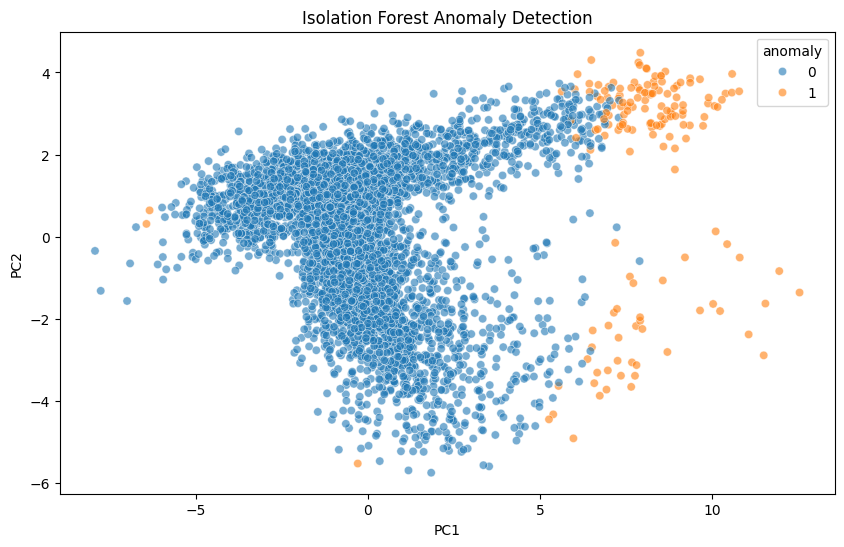

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df.sample(5000),
    x="PC1",
    y="PC2",
    hue="anomaly",
    alpha=0.6
)

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.show()

In [15]:
train_df.to_csv(
    "../data/processed/train_with_anomalies.csv",
    index=False
)

In [16]:
train_df["anomaly_label"].value_counts()

anomaly_label
 1    59411
-1     1838
Name: count, dtype: int64

In [17]:
train_df.groupby(
    "is_anomaly"
)["RUL"].describe()

,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
0,59411.0,136.967615,88.427028,0.0,66.0,126.0,192.0,542.0
1,1838.0,15.129489,38.417181,0.0,3.0,7.0,12.0,456.0
